## 5. Cross-Validation
Running 5-fold cross-validation to confirm model stability across different data 
splits. High variance between folds would suggest overfitting.

**Note:** CV is run on SMOTE-balanced training data, so scores will appear higher 
than test set AUC. The honest performance metric remains the test set AUC of 0.63.

In [1]:
import pandas as pd
import numpy as np
import shap
import pickle
import matplotlib.pyplot as plt

# Load model and data
with open(r'C:\Users\munta\Documents\hospital-readmission-project\models\xgboost_model.pkl', 'rb') as f:
    model = pickle.load(f)

df = pd.read_csv(r'C:\Users\munta\Documents\hospital-readmission-project\data\cleaned_data.csv')

X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']

# Use a sample for SHAP - full dataset is slow
X_sample = X.sample(2000, random_state=42)

print("Data loaded. Calculating SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print("Done!")

Data loaded. Calculating SHAP values...
Done!


## 1. Global Feature Importance
SHAP bar plot shows the mean absolute SHAP value for each feature — i.e. on 
average, how much does each feature contribute to predictions across all patients.

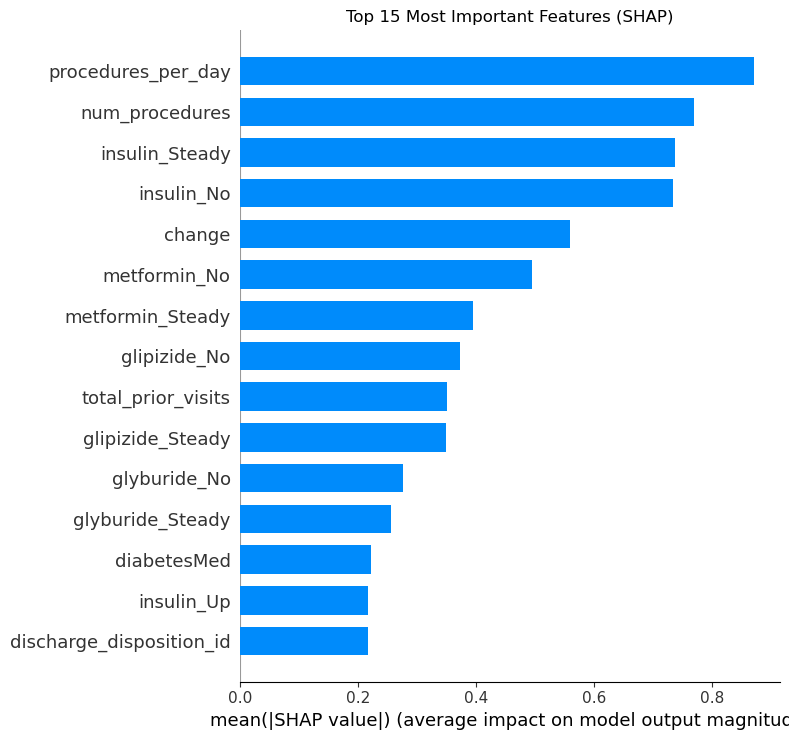

In [2]:
# Summary plot - most important features overall
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15, show=False)
plt.title('Top 15 Most Important Features (SHAP)')
plt.tight_layout()
plt.savefig(r'C:\Users\munta\Documents\hospital-readmission-project\images\shap_bar.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## 2. Feature Impact Direction
The dot plot extends the bar plot by showing both **magnitude** and **direction** 
of each feature's impact.

- Each dot = one patient
- **Pink/Red** = high feature value
- **Blue** = low feature value  
- Position on x-axis = impact on prediction (right = increases readmission risk)

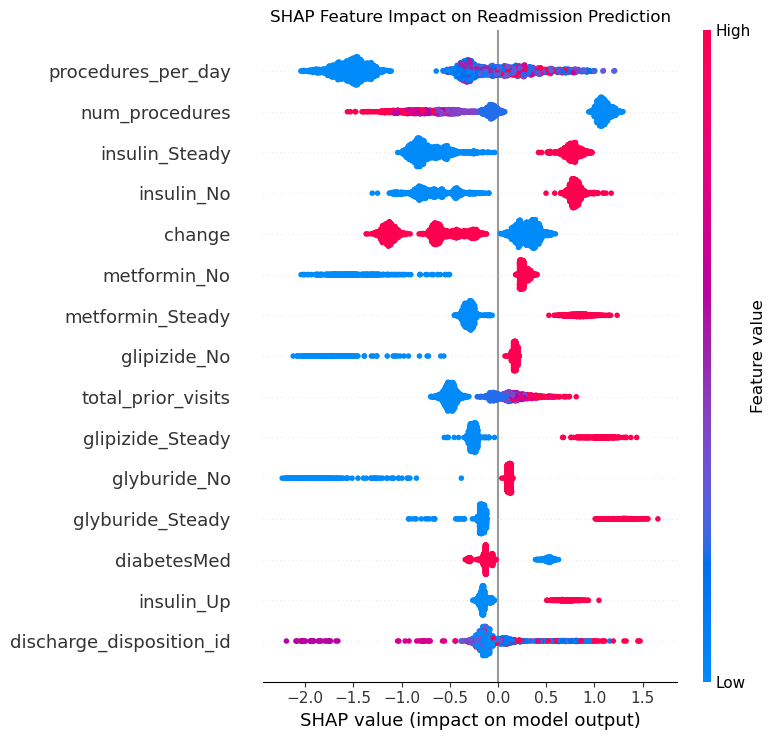

In [3]:
# Dot plot - shows direction of impact too
plt.figure()
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Feature Impact on Readmission Prediction')
plt.tight_layout()
plt.savefig(r'C:\Users\munta\Documents\hospital-readmission-project\images\shap_dot.png', 
            dpi=150, bbox_inches='tight')
plt.show()

### Clinical Interpretation of Key Findings

| Feature | Finding | Clinical Meaning |
|---|---|---|
| `procedures_per_day` | High values → higher risk | Procedural complexity signals sicker patients |
| `total_prior_visits` | High values → higher risk | Prior hospitalisation history is a strong readmission signal |
| `insulin_No` | Not on insulin → higher risk | Counterintuitive — may indicate undertreated diabetes |
| `change` | Medication change → higher risk | Unstable treatment regime may indicate poorly controlled condition |

**Notable:** Two of the top predictors (`procedures_per_day`, `total_prior_visits`) 
are engineered features that did not exist in the raw dataset, validating the 
feature engineering step.